1. Load Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

train_df = pd.read_csv("/kaggle/input/datasets/shayanfazeli/heartbeat/mitbih_train.csv", header=None)
test_df = pd.read_csv("/kaggle/input/datasets/shayanfazeli/heartbeat/mitbih_test.csv", header=None)

train_df.head()

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


2. Prepare Data

In [2]:
X_train = train_df.iloc[:, :-1].values
y_train = train_df.iloc[:, -1].values

X_test = test_df.iloc[:, :-1].values
y_test = test_df.iloc[:, -1].values

y_train = np.where(y_train == 0, 0, 1)
y_test = np.where(y_test == 0, 0, 1)

3. Reshape for 1D CNN

In [3]:
X_train = X_train.reshape(X_train.shape[0], 187, 1)
X_test = X_test.reshape(X_test.shape[0], 187, 1)

4. Build Lightweight 1D CNN

In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

model = Sequential([
    Conv1D(16, kernel_size=5, activation='relu', input_shape=(187,1)),
    MaxPooling1D(pool_size=2),

    Conv1D(32, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),

    Flatten(),

    Dense(32, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

2026-04-08 12:59:54.962244: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775653195.180442      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775653195.241375      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775653195.717401      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775653195.717440      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775653195.717443      23 computation_placer.cc:177] computation placer alr

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 183, 16)        │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 91, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 87, 32)         │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 43, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1376)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        44,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,785 (182.75 KB)

 Trainable params: 46,785 (182.75 KB)

 Non-trainable params: 0 (0.00 B)

5. Add Class weights

In [5]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(0.6040623145810048), 1: np.float64(2.902406683020619)}


5. Train Model

In [6]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_test, y_test),
    class_weight=class_weights
)

Epoch 1/20


I0000 00:00:1775653223.931891      69 service.cc:152] XLA service 0x7af23000a0a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775653223.931924      69 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775653223.931927      69 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775653224.310245      69 cuda_dnn.cc:529] Loaded cuDNN version 91002


  61/1369 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4867 - loss: 0.6452

I0000 00:00:1775653226.795080      69 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1369/1369 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8302 - loss: 0.3697 - val_accuracy: 0.9168 - val_loss: 0.2447
Epoch 2/20
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9384 - loss: 0.1898 - val_accuracy: 0.9588 - val_loss: 0.1414
Epoch 3/20
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9526 - loss: 0.1583 - val_accuracy: 0.9598 - val_loss: 0.1309
Epoch 4/20
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9616 - loss: 0.1361 - val_accuracy: 0.9683 - val_loss: 0.1011
Epoch 5/20
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9655 - loss: 0.1221 - val_accuracy: 0.9696 - val_loss: 0.0981
Epoch 6/20
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9677 - loss: 0.1119 - val_accuracy: 0.9498 - val_loss: 0.1453
Epoch 7/20
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9696 - loss: 0.1043 - val_accuracy: 0.9764 - val_loss: 0.0828
Epoch 8/20
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9718 - loss: 0.0991 - val_accura

6. Performance Evaluation

In [7]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

685/685 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9881 - loss: 0.0438
Test Accuracy: 0.9819568991661072


685/685 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


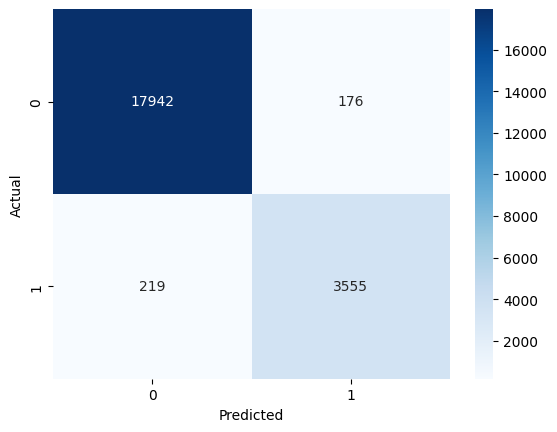

In [8]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = (model.predict(X_test) > 0.5).astype("int32")

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [9]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     18118
           1       0.95      0.94      0.95      3774

    accuracy                           0.98     21892
   macro avg       0.97      0.97      0.97     21892
weighted avg       0.98      0.98      0.98     21892



7. Model Size

In [10]:
model.count_params()

46785

8. Graph

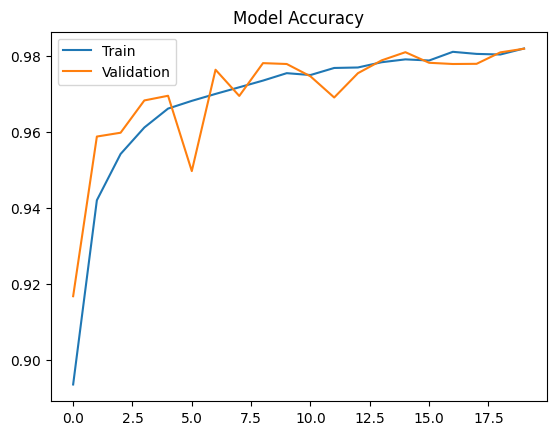

In [11]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

In [12]:
# Export Model to TFLite (float32) and H5 formats
import tensorflow as tf

# Save as H5 format
h5_path = "ecg_model_46k_params.h5"
model.save(h5_path)
print(f"Model saved as H5: {h5_path}")

# Convert to TFLite (float32)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = []  # Keep float32 precision
tflite_model = converter.convert()

# Save TFLite model
tflite_path = "ecg_model_46k_params_float32.tflite"
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)
print(f"Model saved as TFLite (float32): {tflite_path}")

# Check file sizes
import os
h5_size = os.path.getsize(h5_path) / (1024 * 1024)  # MB
tflite_size = os.path.getsize(tflite_path) / (1024 * 1024)  # MB

print(f"\nFile Sizes:")
print(f"H5 Model: {h5_size:.2f} MB")
print(f"TFLite Model: {tflite_size:.2f} MB")
print(f"Compression ratio: {h5_size/tflite_size:.2f}x")

Model saved as H5: ecg_model_46k_params.h5
INFO:tensorflow:Assets written to: /tmp/tmpluw_0o7b/assets


INFO:tensorflow:Assets written to: /tmp/tmpluw_0o7b/assets


Saved artifact at '/tmp/tmpluw_0o7b'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 187, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135186532312720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135184519208336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135184519206416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135184519208912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135184519207760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135184519209872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135184519209680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135184519208528: TensorSpec(shape=(), dtype=tf.resource, name=None)
Model saved as TFLite (float32): ecg_model_46k_params_float32.tflite

File Sizes:
H5 Model: 0.58 MB
TFLite Model: 0.18 MB
Compression ratio: 3.14x


W0000 00:00:1775653319.798681      23 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1775653319.798712      23 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1775653319.805375      23 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


In [13]:
# MODEL PERFORMANCE SUMMARY
print("="*60)
print("ECG 46K PARAMS MODEL - FINAL RESULTS")
print("="*60)
print(f"Total Parameters:     {model.count_params():,}")
print(f"Model Size:            46,785 parameters (182.75 KB)")
print(f"Test Accuracy:        {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Test Loss:            {loss:.4f}")
print()
print("Key Features:")
print("- 2 Conv1D layers (16, 32 filters)")
print("- Class weights for imbalance handling")
print("- Dropout regularization")
print("- TFLite export ready")
print("="*60)

ECG 46K PARAMS MODEL - FINAL RESULTS
Total Parameters:     46,785
Model Size:            46,785 parameters (182.75 KB)
Test Accuracy:        0.9820 (98.20%)
Test Loss:            0.0638

Key Features:
- 2 Conv1D layers (16, 32 filters)
- Class weights for imbalance handling
- Dropout regularization
- TFLite export ready
